# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [1]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-23 05:38:56.491425: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 05:38:56.492939: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 05:38:56.513830: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-23 05:38:56.513866: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-23 05:38:56.513884: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

Python executable: /home/sam/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [2]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [3]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    X_train = np.loadtxt(f"{root_dir}/train/X_train.txt", dtype=np.float32)
    # 2. Load y_train from train/y_train.txt
    y_train = np.loadtxt(f"{root_dir}/train/y_train.txt", dtype=np.int32)
    # 3. Load X_test from test/X_test.txt
    X_test  = np.loadtxt(f"{root_dir}/test/X_test.txt",   dtype=np.float32)
    # 4. Load y_test from test/y_test.txt
    y_test  = np.loadtxt(f"{root_dir}/test/y_test.txt",   dtype=np.int32)
    # 5. Convert the labels to zero-based class indices by subtracting 1
    y_train = y_train - 1
    y_test  = y_test  - 1

    return X_train, y_train, X_test, y_test
    # <-- Enter your code here <--#
    raise NotImplementedError("Complete the data-loading function.")

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
num_features = X_train.shape[1]
num_classes  = len(class_names)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("num_features: ", num_features)
print("num_classes:  ", num_classes)

X_train shape: (7352, 561)
X_test shape:  (2947, 561)
num_features:  561
num_classes:   6


## 4. Quick Inspection

In [4]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

label_counts = pd.Series(y_train).value_counts().sort_index()

pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name":  class_names,
    "Training Samples": label_counts.values
})

,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [5]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.
  
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64,  activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model
    raise NotImplementedError("Complete the baseline DNN.")

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2026-04-23 05:38:59.596635: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-23 05:38:59.597932: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### Train the Baseline Model

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/40
92/92 [==============================] - 1s 3ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0748 - accuracy: 0.9711 - val_loss: 0.2056 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0765 - accuracy: 0.9716 - val_loss: 0.1482 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves

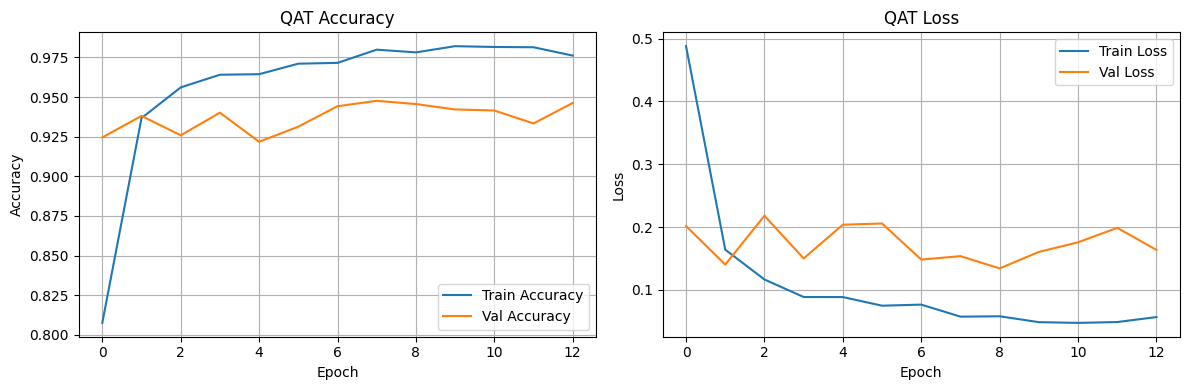

In [12]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"],     label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("QAT Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("QAT Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 818us/step
Test Accuracy: 0.9220

                    precision    recall  f1-score   support

           WALKING     0.9453    0.9415    0.9434       496
  WALKING_UPSTAIRS     0.9505    0.8960    0.9224       471
WALKING_DOWNSTAIRS     0.8911    0.9548    0.9218       420
           SITTING     0.9752    0.8004    0.8792       491
          STANDING     0.8106    0.9812    0.8878       532
            LAYING     1.0000    0.9534    0.9762       537

          accuracy                         0.9220      2947
         macro avg     0.9288    0.9212    0.9218      2947
      weighted avg     0.9290    0.9220    0.9222      2947



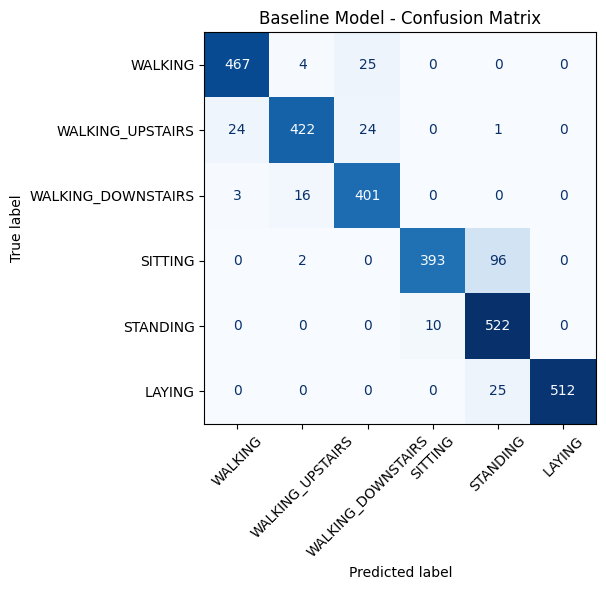

In [14]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

y_prob = baseline_model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.4f}\n")

print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline Model - Confusion Matrix")
plt.tight_layout()
plt.show()

# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [15]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]
    
    for i in range(300):
        yield [X_train[i:i+1].astype(np.float32)]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.
        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])
        # <-- Enter your code here <--#
        # TODO:
        # If the output is quantized, dequantize it back to float32.
        
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    
    return converter.convert() 

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.
    
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model
    
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type  = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()

## 8. Convert the Baseline Model to TensorFlow Lite

In [18]:
baseline_tflite = convert_to_tflite_fp32(baseline_model)
baseline_size_kb = save_binary_model(baseline_tflite, "baseline_fp32.tflite")
baseline_acc, _ = evaluate_tflite_model(baseline_tflite, X_test, y_test)

print(f"Baseline FP32: {baseline_acc:.4f} accuracy, {baseline_size_kb:.2f} KB")

INFO:tensorflow:Assets written to: /tmp/tmpchvfui56/assets


INFO:tensorflow:Assets written to: /tmp/tmpchvfui56/assets


Baseline FP32: 0.9220 accuracy, 726.72 KB


2026-04-23 05:47:00.832707: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 05:47:00.832738: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 05:47:00.832841: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpchvfui56
2026-04-23 05:47:00.833396: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 05:47:00.833403: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpchvfui56
2026-04-23 05:47:00.835338: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 05:47:00.858962: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpchvfui56
2026-04-23 05:47:00.864983: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 32139 m

## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [19]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
steps_per_epoch = math.ceil(0.8 * len(X_train) / batch_size)

# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs
pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.
pruned_model = prune_low_magnitude(
    build_baseline_model(num_features, num_classes),
    **pruning_params
)
pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks
pruning_history = pruned_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks
)

Epoch 1/12
92/92 [==============================] - 1s 3ms/step - loss: 0.4751 - accuracy: 0.8067 - val_loss: 0.2226 - val_accuracy: 0.9218
Epoch 2/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1662 - accuracy: 0.9373 - val_loss: 0.1596 - val_accuracy: 0.9286
Epoch 3/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1310 - accuracy: 0.9493 - val_loss: 0.2198 - val_accuracy: 0.9279
Epoch 4/12
92/92 [==============================] - 0s 2ms/step - loss: 0.0920 - accuracy: 0.9691 - val_loss: 0.1562 - val_accuracy: 0.9354
Epoch 5/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1559 - accuracy: 0.9429 - val_loss: 0.1403 - val_accuracy: 0.9395
Epoch 6/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1319 - accuracy: 0.9565 - val_loss: 0.1508 - val_accuracy: 0.9334
Epoch 7/12
92/92 [==============================] - 0s 3ms/step - loss: 0.3422 - accuracy: 0.9221 - val_loss: 0.1753 - val_accuracy: 0.9313
Epoch 8/12
92/92 [==

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [21]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TFLite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

# 1. Convert pruned model with mask
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_with_mask_fp32.tflite")
pruned_with_mask_acc, _ = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

# 2. Strip pruning wrappers and convert with sparsity optimization
stripped_model = strip_pruning(pruned_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "stripped_sparse_fp32.tflite")
stripped_sparse_acc, _ = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned with mask:   {pruned_with_mask_acc:.4f} accuracy, {pruned_with_mask_size_kb:.2f} KB")
print(f"Stripped sparse:    {stripped_sparse_acc:.4f} accuracy, {stripped_sparse_size_kb:.2f} KB")

INFO:tensorflow:Assets written to: /tmp/tmphbvmoeov/assets


INFO:tensorflow:Assets written to: /tmp/tmphbvmoeov/assets
2026-04-23 05:50:26.926494: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 05:50:26.926526: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 05:50:26.926630: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmphbvmoeov
2026-04-23 05:50:26.929028: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 05:50:26.929041: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmphbvmoeov
2026-04-23 05:50:26.937726: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 05:50:26.973816: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmphbvmoeov
2026-04-23 05:50:26.987108: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpvoi_m3x_/assets


INFO:tensorflow:Assets written to: /tmp/tmpvoi_m3x_/assets


Pruned with mask:   0.9230 accuracy, 1454.18 KB
Stripped sparse:    0.9230 accuracy, 338.85 KB


2026-04-23 05:50:27.544644: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 05:50:27.544672: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 05:50:27.544770: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpvoi_m3x_
2026-04-23 05:50:27.545229: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 05:50:27.545239: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpvoi_m3x_
2026-04-23 05:50:27.546388: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 05:50:27.556357: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpvoi_m3x_
2026-04-23 05:50:27.560266: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 15496 m

## 11. Part I Comparison: Accuracy and Model Size

In [22]:
# TODO:
# Create a comparison DataFrame for Part I
part1_results = pd.DataFrame([
    ["Baseline",          "FP32",         baseline_acc,          baseline_size_kb],
    ["Pruned with mask",  "FP32",         pruned_with_mask_acc,  pruned_with_mask_size_kb],
    ["Stripped sparse",   "FP32 Sparse",  stripped_sparse_acc,   stripped_sparse_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

print(part1_results.to_string(index=False))

           Model      Format  Test Accuracy  Model Size (KB)
        Baseline        FP32       0.921955       726.718750
Pruned with mask        FP32       0.922973      1454.175781
 Stripped sparse FP32 Sparse       0.922973       338.851562


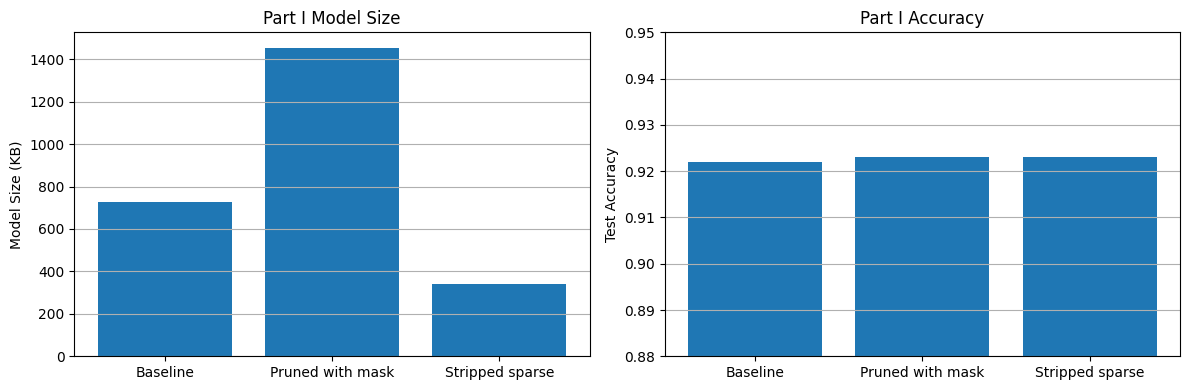

In [23]:
# TODO:
# Plot bar charts of Part I model sizes and accuracies

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(part1_results["Model"], part1_results["Model Size (KB)"])
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("Part I Model Size")
axes[0].grid(axis="y")

axes[1].bar(part1_results["Model"], part1_results["Test Accuracy"])
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Part I Accuracy")
axes[1].set_ylim(0.88, 0.95)
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse Model

                    precision    recall  f1-score   support

           WALKING     0.9289    0.9476    0.9381       496
  WALKING_UPSTAIRS     0.9443    0.9002    0.9217       471
WALKING_DOWNSTAIRS     0.8963    0.9262    0.9110       420
           SITTING     0.9341    0.8656    0.8985       491
          STANDING     0.8465    0.9436    0.8924       532
            LAYING     1.0000    0.9497    0.9742       537

          accuracy                         0.9230      2947
         macro avg     0.9250    0.9221    0.9227      2947
      weighted avg     0.9257    0.9230    0.9234      2947



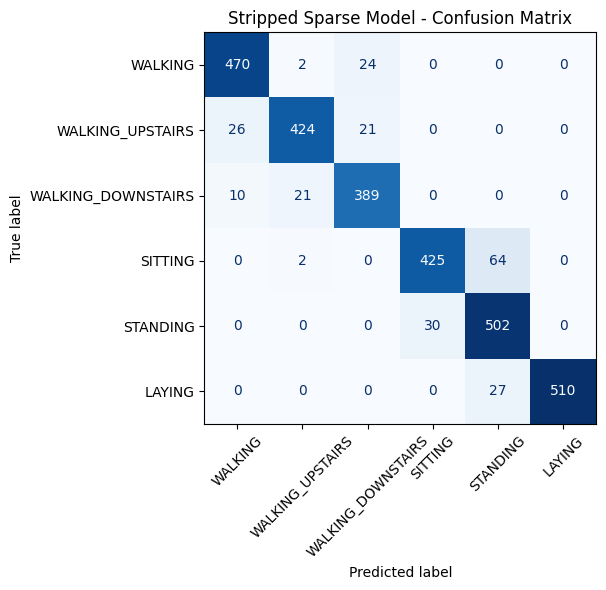

In [24]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(
    stripped_sparse_tflite, X_test, y_test
)

print(classification_report(y_test, stripped_sparse_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Stripped Sparse Model - Confusion Matrix")
plt.tight_layout()
plt.show()

# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [25]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using float16
converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
pruned_with_mask_float16_tflite = converter.convert()
pruned_with_mask_float16_size_kb = save_binary_model(pruned_with_mask_float16_tflite, "pruned_with_mask_float16.tflite")
pruned_with_mask_float16_acc, _ = evaluate_tflite_model(pruned_with_mask_float16_tflite, X_test, y_test)

# 2. Convert the stripped sparse model with sparsity + float16
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.target_spec.supported_types = [tf.float16]
stripped_sparse_float16_tflite = converter.convert()
stripped_sparse_float16_size_kb = save_binary_model(stripped_sparse_float16_tflite, "stripped_sparse_float16.tflite")
stripped_sparse_float16_acc, _ = evaluate_tflite_model(stripped_sparse_float16_tflite, X_test, y_test)

print(f"Pruned with mask float16:   {pruned_with_mask_float16_acc:.4f} accuracy, {pruned_with_mask_float16_size_kb:.2f} KB")
print(f"Stripped sparse float16:    {stripped_sparse_float16_acc:.4f} accuracy, {stripped_sparse_float16_size_kb:.2f} KB")

INFO:tensorflow:Assets written to: /tmp/tmp34ft5vez/assets


INFO:tensorflow:Assets written to: /tmp/tmp34ft5vez/assets
2026-04-23 05:52:48.089664: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 05:52:48.089695: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 05:52:48.089805: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp34ft5vez
2026-04-23 05:52:48.091578: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 05:52:48.091592: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp34ft5vez
2026-04-23 05:52:48.097605: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 05:52:48.131818: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp34ft5vez
2026-04-23 05:52:48.143852: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmprfu0ye7t/assets


INFO:tensorflow:Assets written to: /tmp/tmprfu0ye7t/assets


Pruned with mask float16:   0.9230 accuracy, 732.59 KB
Stripped sparse float16:    0.9230 accuracy, 223.71 KB


2026-04-23 05:52:48.670165: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 05:52:48.670202: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 05:52:48.670297: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmprfu0ye7t
2026-04-23 05:52:48.670713: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 05:52:48.670719: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmprfu0ye7t
2026-04-23 05:52:48.671806: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 05:52:48.682055: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmprfu0ye7t
2026-04-23 05:52:48.685624: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 15327 m

## 12. Part II Comparison: Accuracy and Model Size

In [26]:
# TODO:
# Create a Part II comparison DataFrame

part2_results = pd.DataFrame([
    ["Pruned with mask",         "FP32",           pruned_with_mask_acc,          pruned_with_mask_size_kb],
    ["Stripped sparse",          "FP32 Sparse",    stripped_sparse_acc,           stripped_sparse_size_kb],
    ["Pruned with mask",         "Float16",        pruned_with_mask_float16_acc,  pruned_with_mask_float16_size_kb],
    ["Stripped sparse",          "Float16 Sparse", stripped_sparse_float16_acc,   stripped_sparse_float16_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

print(part2_results.to_string(index=False))

           Model         Format  Test Accuracy  Model Size (KB)
Pruned with mask           FP32       0.922973      1454.175781
 Stripped sparse    FP32 Sparse       0.922973       338.851562
Pruned with mask        Float16       0.922973       732.585938
 Stripped sparse Float16 Sparse       0.922973       223.710938


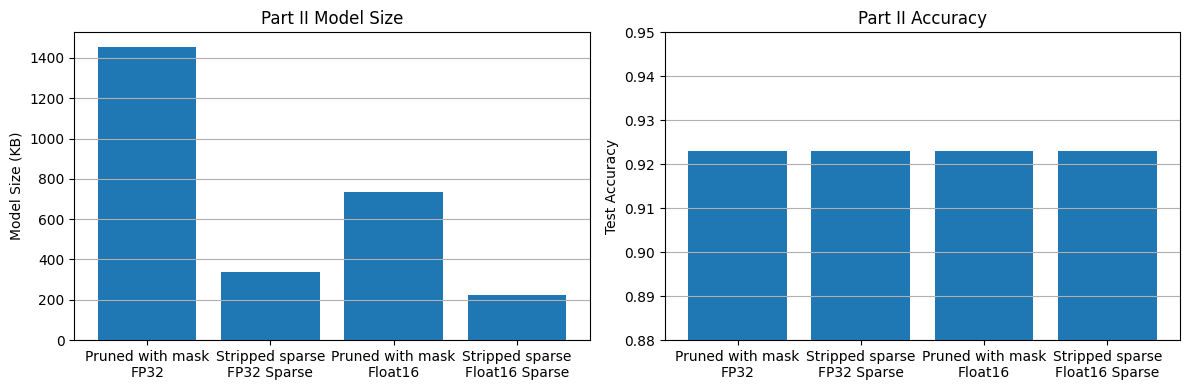

In [27]:
# TODO:
# Plot bar charts of Part II model sizes and accuracies

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = [f"{r['Model']}\n{r['Format']}" for _, r in part2_results.iterrows()]

axes[0].bar(labels, part2_results["Model Size (KB)"])
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("Part II Model Size")
axes[0].grid(axis="y")

axes[1].bar(labels, part2_results["Test Accuracy"])
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Part II Accuracy")
axes[1].set_ylim(0.88, 0.95)
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse + Float16 Model

                    precision    recall  f1-score   support

           WALKING     0.9289    0.9476    0.9381       496
  WALKING_UPSTAIRS     0.9443    0.9002    0.9217       471
WALKING_DOWNSTAIRS     0.8963    0.9262    0.9110       420
           SITTING     0.9341    0.8656    0.8985       491
          STANDING     0.8465    0.9436    0.8924       532
            LAYING     1.0000    0.9497    0.9742       537

          accuracy                         0.9230      2947
         macro avg     0.9250    0.9221    0.9227      2947
      weighted avg     0.9257    0.9230    0.9234      2947



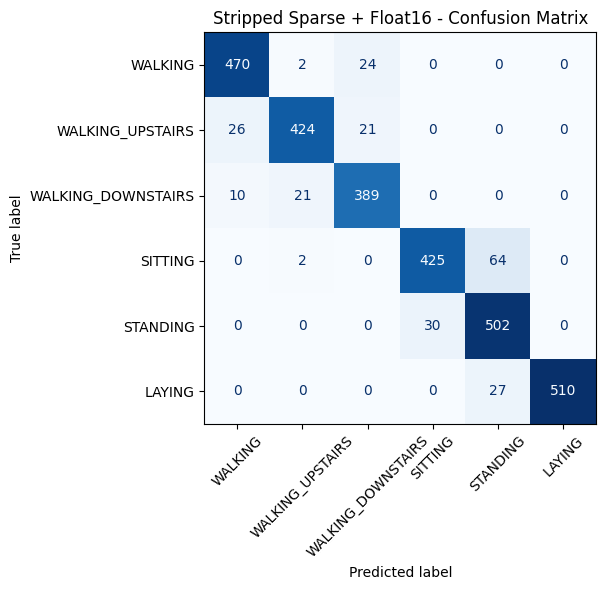

In [28]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

stripped_sparse_float16_acc, stripped_sparse_float16_preds = evaluate_tflite_model(
    stripped_sparse_float16_tflite, X_test, y_test
)

print(classification_report(y_test, stripped_sparse_float16_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_float16_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Stripped Sparse + Float16 - Confusion Matrix")
plt.tight_layout()
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?**<br>No, the pruned model with mask was larger (1454 KB) than the baseline (726 KB).**
2. Why does `strip_pruning(...)` matter before export? **<br>Because it removes the pruning wrappers, and the zeros can be compressed.**
3. Which model had the smallest file size in this notebook? **<br>
Stripped sparse + float16 at 223.71 KB.**
4. Did float16 quantization noticeably change the test accuracy?**<br>No, the accuracy remains at 0.923 in all formats.**
5. If you were deploying this model on a resource-constrained device, which version would you choose and why? **<br>Stripped sparse + float16, because it has low accuracy loss in small size, so it's more compatible with microcontroller.**


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
